## Access Mooring Estuarine Coastal Water Quality Monitoring Realtime QC (Parquet)

This Jupyter notebook demonstrates how to access and plot mooring_estuarine_coastal_water_quality_monitoring_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/a8f5c736-6eaa-47fb-a9eb-d778beb71701).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/mooring_estuarine_coastal_water_quality_monitoring_realtime_qc.ipynb).


In [1]:
dataset_name = "mooring_estuarine_coastal_water_quality_monitoring_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.3 environment at: /home/mphemming/Documents/GitHub/aodn_cloud_optimised/.venv
Resolved 201 packages in 571ms
Checked 201 packages in 2ms


✅ Local version 0.3.30 is up to date (remote: 0.3.30)


In [3]:
from DataQuery import GetAodn

/home/mphemming/Documents/GitHub/aodn_cloud_optimised/notebooks/DataQuery.py:4856: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 6.22 ms, sys: 3.07 ms, total: 9.28 ms
Wall time: 16.3 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

site_code: string
timestamp: int32
polygon: string

## List unique partition values

In [14]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('site_code')
print(list(unique_partition_value))  # showing a subset only

['SA-AMERICAN-RIVER', 'SA-VICTOR-HARBOR', 'SA-COFFIN-BAY', 'SA-BOSTON-BAY', 'SA-ST-KILDA', 'SA-STANSBURY']
CPU times: user 578 µs, sys: 0 ns, total: 578 µs
Wall time: 517 µs


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/mphemming/Documents/GitHub/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


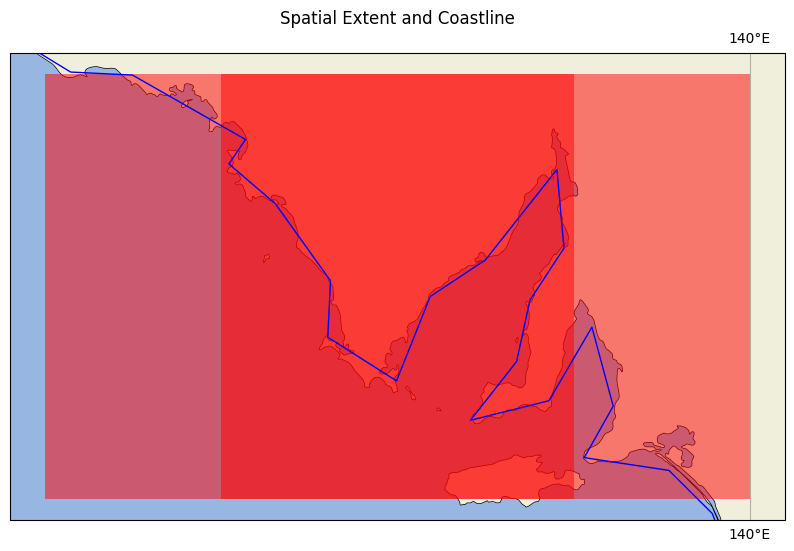

In [15]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similarly to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarily accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 80.6 ms, sys: 19.3 ms, total: 100 ms
Wall time: 479 ms


(Timestamp('2026-01-22 22:33:54.999998976'), Timestamp('2026-09-07 22:30:00'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-09-08 09:09:51,858 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/mooring_estuarine_coastal_water_quality_monitoring_realtime_qc.parquet


{'TEMP': {'type': 'float',
  'ancillary_variables': 'TEMP_quality_control',
  'standard_name': 'sea_water_temperature',
  'long_name': 'sea_water_temperature',
  'units': 'degC',
  'valid_min': -2.5,
  'valid_max': 40.0},
 'TEMP_quality_control': {'type': 'float',
  'flag_meanings': 'pass not_evaluated questionable bad missing',
  'flag_values': [1, 2, 3, 4, 9],
  'long_name': 'quality flag for sea_water_temperature',
  'quality_control_conventions': 'Ocean Data Standards, UNESCO 2013 - IOC Manuals and Guides, 54, Volume 3 Version 1',
  'standard_name': 'sea_water_temperature status_flag'},
 'DEPTH': {'type': 'double',
  'long_name': 'actual depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standard_name': 'depth',
  'comment': 'Depth computed using the Gibbs-SeaWater toolbox (TEOS-10) from latitude and relative pressure measurements (calibration offset usually performed to balance current atmospheric pressure and acute sensor precision at a deployed depth).',
  'uni

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [16]:
%%time
df = aodn_dataset.get_data(date_start='2026-01-01', 
                           date_end='2026-03-01',
                           lat_min=-42, 
                           lat_max=-28, 
                           lon_min=130, 
                           lon_max=150, 
                           )

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5287 entries, 0 to 5286
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   TEMP                        5287 non-null   float32       
 1   TEMP_quality_control        5287 non-null   float32       
 2   LATITUDE_GPS                5287 non-null   float64       
 3   LONGITUDE_GPS               5287 non-null   float64       
 4   TIME                        5287 non-null   datetime64[ns]
 5   NOMINAL_DEPTH               5287 non-null   float32       
 6   LATITUDE                    5287 non-null   float64       
 7   LONGITUDE                   5287 non-null   float64       
 8   FLUSI                       4422 non-null   float32       
 9   FLUSI_quality_control       4422 non-null   float32       
 10  CPHL_PPB                    4422 non-null   float32       
 11  CPHL_PPB_quality_control    4422 non-null   float32     

In [17]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


df.aodn.download_as_csv()

/home/mphemming/Documents/GitHub/aodn_cloud_optimised/notebooks/aodn_metadata-uuid_f3c16fdb-72fc-4b55-bff1-3b5b5722f38f_mooring_estuarine_coastal_water_quality_monitoring_realtime_qc_data-hash_9de84ce7.csv.zip

## Create a TIME and scalar/number filter

This cell filters the dataset by time range and a scalar value (from a Parquet partition) using the `scalar_filter` argument.  
This leverages Parquet partitioning to apply efficient, server-side filtering, which significantly speeds up data loading.

In [23]:
%%time
df = aodn_dataset.get_data(date_start='2025-01-01', 
                           date_end='2026-09-01',
                           scalar_filter={'site_code': 'SA-VICTOR-HARBOR'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19785 entries, 0 to 19784
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   TEMP                        19785 non-null  float32       
 1   TEMP_quality_control        19785 non-null  float32       
 2   LATITUDE_GPS                19785 non-null  float64       
 3   LONGITUDE_GPS               19785 non-null  float64       
 4   TIME                        19785 non-null  datetime64[ns]
 5   NOMINAL_DEPTH               19785 non-null  float32       
 6   LATITUDE                    19785 non-null  float64       
 7   LONGITUDE                   19785 non-null  float64       
 8   FLUSI                       9892 non-null   float32       
 9   FLUSI_quality_control       9892 non-null   float32       
 10  CPHL_PPB                    9892 non-null   float32       
 11  CPHL_PPB_quality_control    9892 non-null   float32   

In [27]:
print('SA-VICTOR-HARBOR Data')
SAVH_df = df[df['site_code'] == 'SA-VICTOR-HARBOR']
SAVH_df

SA-VICTOR-HARBOR Data


,TEMP,TEMP_quality_control,LATITUDE_GPS,LONGITUDE_GPS,TIME,NOMINAL_DEPTH,LATITUDE,LONGITUDE,FLUSI,FLUSI_quality_control,...,SPEC_CNDC_quality_control,PHYCOE_rfu,TURB,PHYCOE_rfu_quality_control,TURB_quality_control,PHYCOE,PHYCOE_quality_control,site_code,timestamp,polygon
0,13.967000,1.0,-35.559414,138.636093,2026-05-20 23:00:00,0.9,-35.533,138.697,NaN,NaN,...,4.0,NaN,24.200001,NaN,1.0,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
1,16.694679,1.0,-35.559414,138.636093,2026-05-20 23:04:25,0.9,-35.533,138.697,1.618033,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
2,16.642000,4.0,-35.559414,138.636093,2026-05-20 23:15:00,0.9,-35.533,138.697,NaN,NaN,...,4.0,NaN,4.560000,NaN,1.0,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
3,16.746040,1.0,-35.559414,138.636093,2026-05-20 23:19:25,0.9,-35.533,138.697,1.602606,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
4,16.839001,1.0,-35.559414,138.636093,2026-05-20 23:30:00,0.9,-35.533,138.697,NaN,NaN,...,3.0,NaN,2.920000,NaN,1.0,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19780,14.912000,1.0,-35.560738,138.635788,2026-08-31 23:30:00,0.9,-35.533,138.697,NaN,NaN,...,1.0,NaN,4.360000,NaN,1.0,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
19781,14.875800,1.0,-35.560738,138.635788,2026-08-31 23:34:25,0.9,-35.533,138.697,1.285754,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
19782,14.911000,1.0,-35.560738,138.635788,2026-08-31 23:45:00,0.9,-35.533,138.697,NaN,NaN,...,1.0,NaN,4.520000,NaN,1.0,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...
19783,14.881000,1.0,-35.560738,138.635788,2026-08-31 23:49:25,0.9,-35.533,138.697,1.314252,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-VICTOR-HARBOR,1767225600,0103000000010000000500000000000000000061400000...


In [30]:
df = aodn_dataset.get_data(date_start='2025-01-01', 
                           date_end='2026-09-01',
                           scalar_filter={'site_code': 'SA-AMERICAN-RIVER'})
print('SA-AMERICAN-RIVER Data')
SAAR_df = df[df['site_code'] == 'SA-AMERICAN-RIVER']
SAAR_df

SA-AMERICAN-RIVER Data


,TEMP,TEMP_quality_control,LATITUDE_GPS,LONGITUDE_GPS,TIME,NOMINAL_DEPTH,LATITUDE,LONGITUDE,FLUSI,FLUSI_quality_control,...,SPEC_CNDC_quality_control,PHYCOE_rfu,TURB,PHYCOE_rfu_quality_control,TURB_quality_control,PHYCOE,PHYCOE_quality_control,site_code,timestamp,polygon
0,14.63800,1.0,-35.727283,137.838455,2026-06-21 23:30:00.000000000,0.9,-35.758,137.876,NaN,NaN,...,1.0,NaN,3.410000,NaN,1.0,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
1,14.59060,1.0,-35.727283,137.838455,2026-06-21 23:33:54.999998976,0.9,-35.758,137.876,1.774423,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
2,14.64200,1.0,-35.727283,137.838455,2026-06-21 23:45:00.000000000,0.9,-35.758,137.876,NaN,NaN,...,1.0,NaN,3.210000,NaN,1.0,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
3,14.58748,1.0,-35.727283,137.838455,2026-06-21 23:48:54.999998976,0.9,-35.758,137.876,1.758571,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
4,14.64000,1.0,-35.727283,137.838455,2026-06-22 00:00:00.000000000,0.9,-35.758,137.876,NaN,NaN,...,1.0,NaN,3.080000,NaN,1.0,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13632,14.95400,1.0,-35.727276,137.838409,2026-08-31 23:30:00.000000000,0.9,-35.758,137.876,NaN,NaN,...,1.0,NaN,21.209999,NaN,1.0,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
13633,14.92232,1.0,-35.727276,137.838409,2026-08-31 23:33:54.999998976,0.9,-35.758,137.876,2.208583,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
13634,14.97000,1.0,-35.727276,137.838409,2026-08-31 23:45:00.000000000,0.9,-35.758,137.876,NaN,NaN,...,1.0,NaN,21.090000,NaN,1.0,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...
13635,14.93968,1.0,-35.727276,137.838409,2026-08-31 23:48:54.999998976,0.9,-35.758,137.876,2.636229,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SA-AMERICAN-RIVER,1767225600,010300000001000000050000000000000000C060400000...


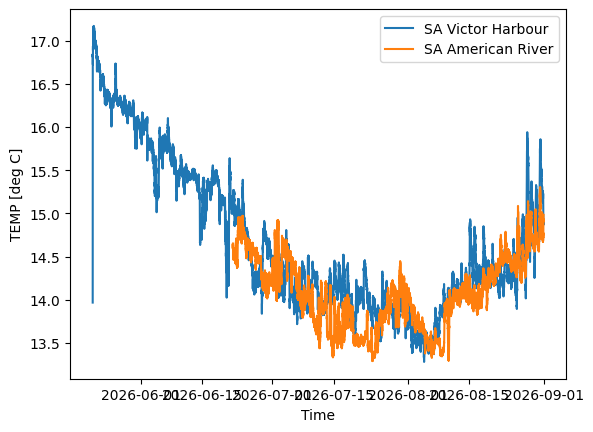

In [35]:
import matplotlib.pyplot as plt

# Create a plot comparing the temperature data from different sites
plt.plot(SAVH_df['TIME'], SAVH_df['TEMP'],label='SA Victor Harbour')
plt.plot(SAAR_df['TIME'], SAAR_df['TEMP'],label='SA American River')
# Add a legend to the plot
plt.legend()
# Set the labels for the x and y axes
plt.xlabel('Time')
plt.ylabel('TEMP [deg C]')
plt.show()
